In [1]:
!rm /content/NTU2025Fall -rf
!git clone https://github.com/frankguo77/NTU2025Fall.git

Cloning into 'NTU2025Fall'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 96 (delta 30), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 11.78 MiB | 9.04 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [2]:
import sys
sys.path.append("/content/NTU2025Fall/on-policy-rl")

In [3]:
!pip install swig
!pip install gymnasium[box2d]
!pip install pyvirtualdisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 36.4 MB/s eta 0:00:00


In [4]:
import numpy as np
import torch
import torch.optim as optim
from collections import deque
import time
from tqdm import tqdm

# Import our RL utilities
from rl_utils import (
    set_seeds,
    PolicyNetwork,
    create_env_with_wrappers,
    plot_training_results,
    plot_variance_analysis,
)

# Create configuration
CONFIG = {
    "seed": 42,
    "episodes": 5000,
    "gamma": 0.99,
    "lr": 5e-4,
    "device": "cpu",
    "window_length": 100,
    "target_score": 200,  # LunarLander-v3 target score
    # Environment: LunarLander-v3 only
    "env_id": "LunarLander-v3",
    "env_kwargs": {
        "gravity": -10.0,
        "enable_wind": False,
        "wind_power": 15.0,
        "turbulence_power": 1.5,
    },
    # Video Recording Config
    "record_videos": True,
    "video_folder": "videos",
    "num_videos": 9,  # Number of videos to record during training
    "record_test_videos": True,
    # Neural Network Config
    "policy_network": {
        "fc_out_features": [64, 64, 64],
        "activation": "SiLU",
        "use_layer_norm": True,
        "dropout_rate": 0.0,
    },
}

set_seeds(CONFIG["seed"])
print(f"🎲 Global random seeds set to {CONFIG['seed']} for reproducible results")
print(
    f"📝 Environment episodes will use seeds {CONFIG['seed']} + episode_number for varied but reproducible episodes"
)

🎲 Global random seeds set to 42 for reproducible results
📝 Environment episodes will use seeds 42 + episode_number for varied but reproducible episodes


In [22]:
class ReinforceAgent:
  def __init__(self, policy_network, config):
    self.policy = policy_network.to(config["device"])
    self.optimizer = optim.Adam(self.policy.parameters(), lr=config["lr"])
    self.gamma = config["gamma"]
    self.device = config["device"]
    self.window_size = config.get("window_length")

    # Print detailed network information including parameter count
    print(f"📊 POLICY NETWORK DETAILS:")
    self.policy.print_network_info()

    # Episode-specific storage
    self.log_probs = []
    self.rewards = []

    # Gradient tracking for variance analysis
    self.gradient_norms = []
    self.episode_scores = []  # Raw undiscounted episode scores
    self.episode_returns = []  # Discounted episode returns (G_0)
    self.score_variance_history = []
    self.return_variance_history = []

    # Update step tracking - separate from episode numbers
    self.update_step = 0
    self.update_steps_history = (
        []
    )  # Track which update step each loss/gradient corresponds to

    self.loss_history = {
        "policy_loss": [],
        "total_loss": [],  # For REINFORCE, total_loss == policy_loss
    }

  def select_action(self, state):
    """Select an action from the policy distribution."""
    # Normalize observation before feeding to network

    state = torch.as_tensor(state, dtype=torch.float32, device=self.device)
    dist = self.policy(state)
    action = dist.sample()

    if self.policy.is_continuous:
      log_prob = dist.log_prob(action)
      # Use the policy network's clip_action method for proper bounds
      action_to_env = self.policy.clip_action(action).flatten()
    else:
      log_prob = dist.log_prob(action)
      action_to_env = action.item()

    self.log_probs.append(log_prob)
    return action_to_env

  def update_policy(self):
    """Update the policy network using the collected episode data."""
    if not self.log_probs:
      return {"policy_loss": 0.0, "total_loss": 0.0}, 0.0

    # Increment update step counter
    self.update_step += 1

    # 1. Calculate discounted returns (G_t)
    return_list = []
    for rewards in self.rewards:
      returns = np.zeros_like(rewards)
      discounted_reward = 0
      for i in range(len(rewards) - 1, -1, -1):
        discounted_reward = rewards[i] + self.gamma * discounted_reward
        returns[i] = discounted_reward
      return_list.append(returns)

    returns = np.concatenate(return_list)

    returns = torch.as_tensor(returns,dtype=torch.float32, device=self.device)
    # Store both episode score and discounted return for variance tracking
    episode_score = [sum(r) for r in self.rewards] # Raw undiscounted sum
    episode_return = [r[0] if len(r) > 0 else 0.0 for r in return_list]  # Discounted G_0
    self.episode_scores.extend(episode_score)
    self.episode_returns.extend(episode_return)
    # Track both score and return variance over recent episodes
    if len(self.episode_scores) >= self.window_size:
      recent_scores = self.episode_scores[-self.window_size:]
      score_variance = np.var(recent_scores)
      self.score_variance_history.append(score_variance)

      recent_returns = self.episode_returns[-self.window_size:]
      return_variance = np.var(recent_returns)
      self.return_variance_history.append(return_variance)
    # 2. Normalize returns for stability (a common trick for REINFORCE)
    returns_normalized = (returns - returns.mean()) / (returns.std() + 1e-8)
    log_probs_tensor = torch.stack(self.log_probs)
    policy_loss = -(log_probs_tensor * returns_normalized).mean()
    # 4. Update policy network and track gradients
    self.optimizer.zero_grad()
    policy_loss.backward()

    # Calculate gradient norm before clipping/updating
    total_grad_norm = 0.0
    for param in self.policy.parameters():
      if param.grad is not None:
        param_norm = param.grad.data.norm(2)
        total_grad_norm += param_norm

    total_grad_norm = total_grad_norm ** (1.0 / 2)
    self.gradient_norms.append(total_grad_norm)

    self.optimizer.step()
    # 5. Store loss components and corresponding update step
    policy_loss_value = policy_loss.item()
    total_loss_value = policy_loss_value # For REINFORCE, total == policy
    self.loss_history["policy_loss"].append(policy_loss_value)
    self.loss_history["total_loss"].append(total_loss_value)
    self.update_steps_history.append(self.update_step)

    # 6. Clear episode storage
    self.log_probs = []
    self.rewards = []

    return {
        "policy_loss": policy_loss_value,
        "total_loss": total_loss_value,
    }, total_grad_norm

  def get_variance_stats(self):
      """Get variance statistics for analysis - all calculated from last N episodes."""
      if len(self.episode_scores) < 2:
          return {
              "gradient_norm_mean": 0.0,
              "gradient_norm_std": 0.0,
              "score_mean": 0.0,
              "score_std": 0.0,
              "return_mean": 0.0,
              "return_std": 0.0,
              "recent_score_variance": 0.0,
              "recent_return_variance": 0.0,
              "gradient_cv": 0.0,
              "score_cv": 0.0,
          }

      # Calculate ALL statistics from the SAME window (last N episodes)
      final_window_size = min(self.window_size, len(self.episode_scores))
      recent_scores = self.episode_scores[-final_window_size:]
      recent_returns = self.episode_returns[-final_window_size:]
      recent_gradients = self.gradient_norms[-final_window_size:] if len(self.gradient_norms) >= final_window_size else self.gradient_norms

      # Calculate means and standard deviations
      gradient_mean = np.mean(recent_gradients) if recent_gradients else 0.0
      gradient_std = np.std(recent_gradients) if len(recent_gradients) > 1 else 0.0
      score_mean = np.mean(recent_scores)
      score_std = np.std(recent_scores)

      # Calculate Coefficient of Variation (CV = std / mean)
      gradient_cv = gradient_std / gradient_mean if gradient_mean > 0 else 0.0
      score_cv = score_std / score_mean if score_mean != 0 else 0.0

      return {
          "gradient_norm_mean": gradient_mean,
          "gradient_norm_std": gradient_std,
          "score_mean": score_mean,
          "score_std": score_std,
          "return_mean": np.mean(recent_returns),
          "return_std": np.std(recent_returns),
          "recent_score_variance": np.var(recent_scores),
          "recent_return_variance": np.var(recent_returns),
          "gradient_cv": gradient_cv,
          "score_cv": score_cv,
      }


In [23]:
def train_reinforce(is_continuous, config):
    """Main training loop for the REINFORCE agent."""
    action_type = "Continuous" if is_continuous else "Discrete"
    print(f"\n{'='*60}")
    print(f"REINFORCE ({action_type.upper()}) TRAINING")
    print(f"{'='*60}")

    # Calculate video recording interval
    video_record_interval = max(1, config["episodes"] // config["num_videos"])
    print(f"📹 Recording {config['num_videos']} videos every {video_record_interval} episodes")

    # Create algorithm-specific video folder
    video_folder = f"/content/videos/REINFORCE_{action_type.lower()}"
    config_with_videos = config.copy()
    config_with_videos["video_folder"] = video_folder
    config_with_videos["video_record_interval"] = video_record_interval

    # Create Environment (this will automatically clean up existing videos)
    env = create_env_with_wrappers(
        config_with_videos,
        is_continuous,
        record_videos=True,
        video_prefix=f"reinforce_{action_type.lower()}",
        cleanup_existing=True
    )

    # Get observation dimension and space
    dummy_obs, _ = env.reset()
    observation_dim = len(dummy_obs)

    # Create Policy Network and Agent
    print(f"\n🏗️ CREATING {action_type.upper()} POLICY NETWORK:")
    policy_net = PolicyNetwork(
        observation_dim=observation_dim,
        action_space=env.action_space,
        is_continuous=is_continuous,
        network_config=config["policy_network"]
    )

    print(f"\n🤖 INITIALIZING {action_type.upper()} REINFORCE AGENT:")
    agent = ReinforceAgent(policy_net, config)

    # Training Loop
    scores = []
    scores_window = deque(maxlen=config["window_length"])
    start_time = time.time()

    print(f"\n🚀 STARTING {action_type.upper()} TRAINING...")

    # Use tqdm for progress bar with detailed information
    pbar = tqdm(range(1, config["episodes"] + 1), desc="Training", unit="episode")

    for i_episode in pbar:
      for j in range(5):
        state, _ = env.reset(seed=config["seed"] + j * 10000 + i_episode)
        ep_rewards = []

        ep_reward = 0
        while True:
            action = agent.select_action(state)

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            ep_rewards.append(reward)
            # agent.rewards.append(reward)
            ep_reward += reward

            state = next_state

            if done:
               agent.rewards.append(ep_rewards)
               break
        scores.append(ep_reward)
        scores_window.append(ep_reward)

      loss_dict, grad_norm = agent.update_policy()

      # Update tqdm description with current statistics - use specific loss names
      avg_score_window = np.mean(scores_window) if len(scores_window) > 0 else 0.0
      policy_loss = loss_dict['policy_loss'] if loss_dict['policy_loss'] is not None else 0.0
      total_loss = loss_dict['total_loss'] if loss_dict['total_loss'] is not None else 0.0


      pbar.set_description(
          f"Ep {i_episode:4d} | "
          f"Score: {ep_reward:6.1f} | "
          f"AvgScore({config['window_length']}): {avg_score_window:6.1f} | "
          f"PolicyLoss: {policy_loss:8.4f} | "
          f"TotalLoss: {total_loss:8.4f} | "
          f"GradNorm: {grad_norm:6.4f}"
      )

      if avg_score_window > 250:
        print(f"\n🎉 Early stopped at avg sccore: {avg_score_window}.")
        break

      # Handle video display - show all videos collected so far
      # if i_episode % video_record_interval == 0 and config["record_videos"]:
      #     from rl_utils.environment import display_latest_video
      #     pbar.write(f"\nVideo recorded at episode {i_episode}")
      #     display_latest_video(
      #         config_with_videos["video_folder"],
      #         f"reinforce_{action_type.lower()}",
      #         i_episode
      #     )

    pbar.close()
    env.close()

    elapsed_time = time.time() - start_time
    # Use config window size for final performance calculation
    final_window_size = min(config["window_length"], len(scores))
    final_performance = np.mean(scores[-final_window_size:]) if final_window_size > 0 else 0.0
    print(f"\n{action_type} training completed in {elapsed_time:.1f} seconds!")

    return scores, agent.loss_history, agent

In [24]:
# --- DISCRETE ACTION SPACE TRAINING ---
print("Starting REINFORCE training with DISCRETE actions...")

discrete_scores, discrete_losses, discrete_agent = train_reinforce(is_continuous=False, config=CONFIG)

Starting REINFORCE training with DISCRETE actions...

REINFORCE (DISCRETE) TRAINING
📹 Recording 9 videos every 555 episodes

🏗️ CREATING DISCRETE POLICY NETWORK:

🤖 INITIALIZING DISCRETE REINFORCE AGENT:
📊 POLICY NETWORK DETAILS:
Policy Network Info:
  Action Type: Discrete
  Total Trainable Parameters: 9540

Action space: 4 discrete actions

🚀 STARTING DISCRETE TRAINING...


Ep  110 | Score: -196.3 | AvgScore(100):  -60.3 | PolicyLoss:  -0.0037 | TotalLoss:  -0.0037 | GradNorm: 0.9746:   2%|▏         | 110/5000 [01:55<3:05:10,  2.27s/episode]/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
Ep  641 | Score:  251.1 | AvgScore(100):  250.5 | PolicyLoss:  -0.0012 | TotalLoss:  -0.0012 | GradNorm: 0.9883:  13%|█▎        | 640/5000 [52:09<5:55:20,  4.89s/episode]


🎉 Early stopped at avg sccore: 250.5324573941134.

Discrete training completed in 3129.6 seconds!


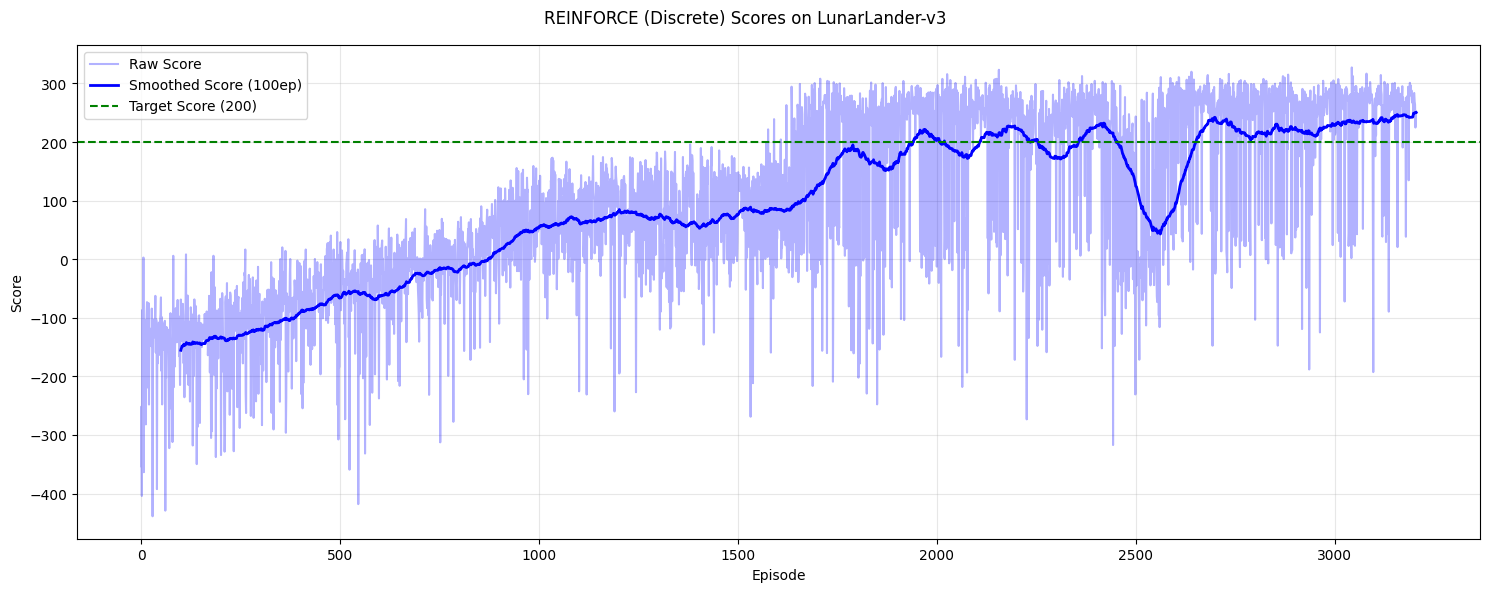

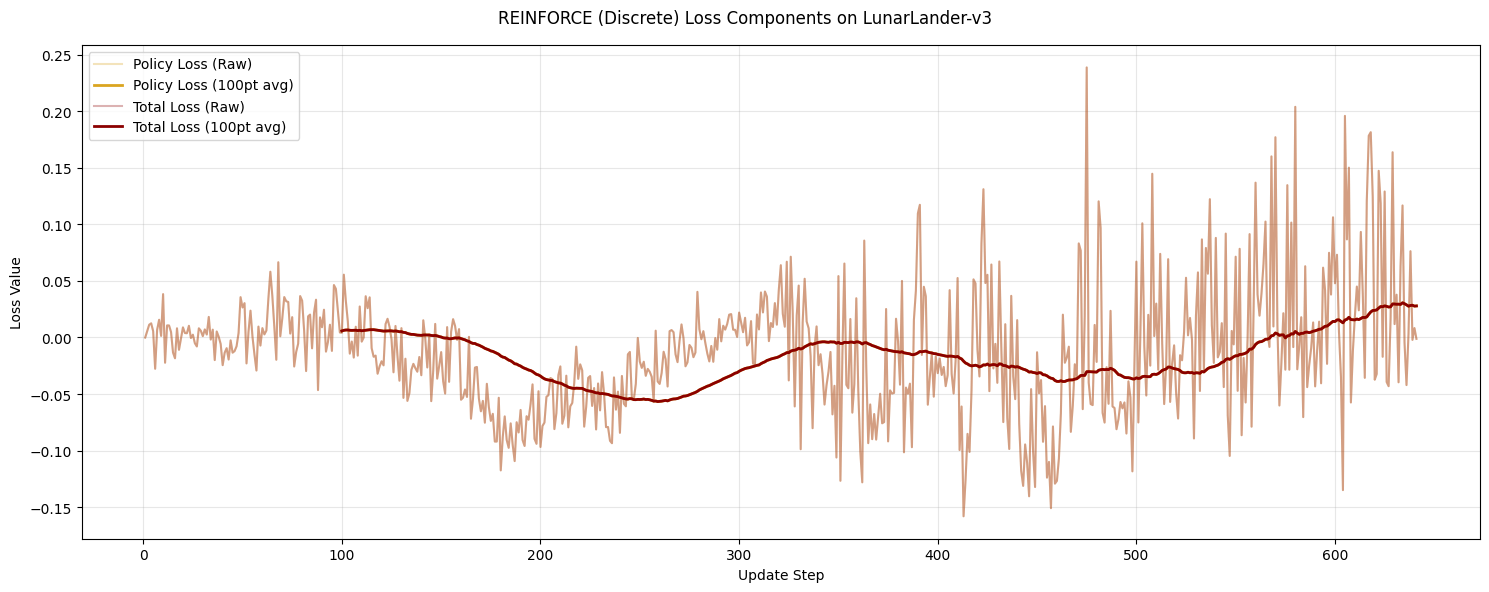

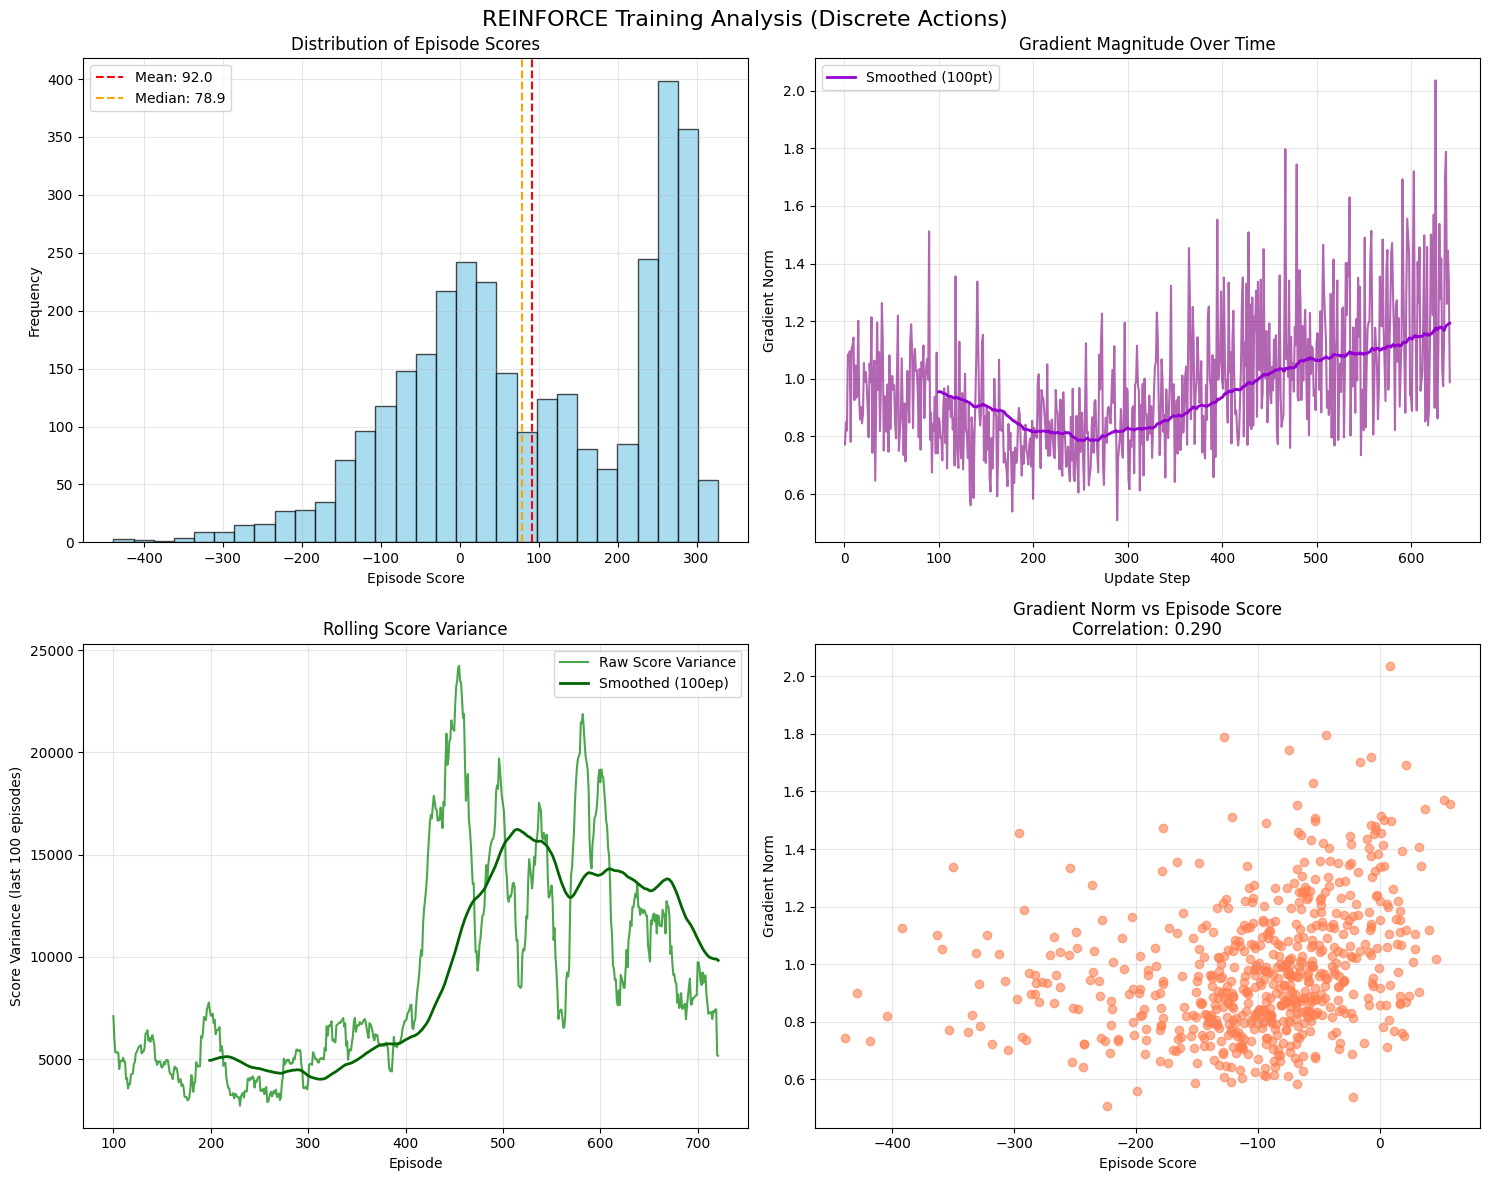

In [25]:
# Plot training results with REINFORCE-specific analysis
plot_training_results(discrete_scores, discrete_agent.loss_history, CONFIG, "Discrete", algorithm_name="REINFORCE")

# Show variance analysis with REINFORCE-specific commentary
plot_variance_analysis(discrete_agent, discrete_scores, "Discrete", CONFIG, algorithm_name="REINFORCE")

# Training completion message
final_window_size = min(CONFIG["window_length"], len(discrete_scores))
final_avg = np.mean(discrete_scores[-final_window_size:]) if final_window_size > 0 else 0.0

In [26]:
import os, glob
pattern = os.path.join("/content/videos/REINFORCE_discrete/", f"reinforce_discrete-episode-*.mp4")
video_files = glob.glob(pattern)
print(f"📹 {len(video_files)} training videos available ")

📹 9 training videos available 


-167.2421712372183
268.2946282042261
47.452934527741164
279.01854374311455
281.5323066764429


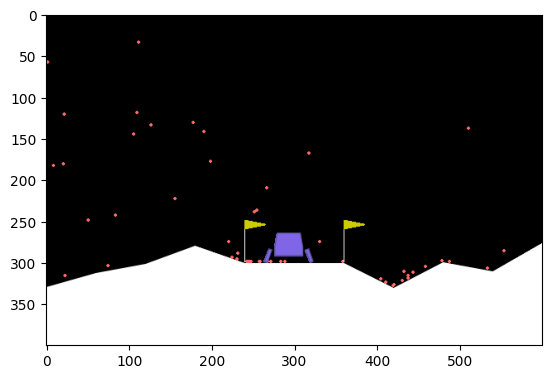

In [33]:
# fix(env, seed)
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make('LunarLander-v3', render_mode="rgb_array")
discrete_agent.policy.eval()  # set the network into evaluation mode
NUM_OF_TEST = 5 # Do not revise this !!!
test_total_reward = []
action_list = []
for i in range(NUM_OF_TEST):
  actions = []
  state,_ = env.reset()

  img = plt.imshow(env.render())

  total_reward = 0

  done = False
  truncated = False
  while not (done or truncated):
    with torch.no_grad():
      action  = discrete_agent.select_action(state)
      actions.append(action)
      state, reward, done, truncated, _ = env.step(action)

      total_reward += reward

      # img.set_data(env.render())
      # display.display(plt.gcf())
      # display.clear_output(wait=True)

  print(total_reward)
  img = plt.imshow(env.render())
  # display.display(plt.gcf())
  test_total_reward.append(total_reward)

  action_list.append(actions) # save the result of testing
